### 生成数据

注意：这个部分是根据**条件均匀分布**的机制生成的数据，如果要在后续分析中使用真实数据，请直接运行**导入数据**模块的代码。

In [162]:
import csv
import random
import math

# 用户输入
number = int(input("输入红包个数"))
money = float(input("输入每个红包金额"))
people = int(input("输入人数"))

# 检查人数是否过多
if people > money * 100:
    print("people is too many")
else:
    # 创建CSV文件
    with open('envelopes.csv', 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        
        # 写入表头
        header = ['Trial'] + [f'Person{p}' for p in range(1, people + 1)]
        writer.writerow(header)
        
        # 存储所有试验结果
        all_results = []
        
        # 执行number次试验
        for j in range(number):
            envelopes = []
            remaining_money = money
            
            for i in range(people):
                # 计算剩余人数
                remaining_people = people - i
                
                # 计算剩余钱的平均值
                avg_money = remaining_money / remaining_people
                
                # 计算最大可分配金额
                max_possible_avg = min(avg_money * 2, 
                                     remaining_money - (remaining_people - 1) * 0.01)
                min_amount = max(0.01, 0.1*avg_money)
                max_amount = max(max_possible_avg, min_amount)
                
                # 如果是最后一个人，给他所有剩余的钱
                if i == people - 1:
                    money_get = round(remaining_money, 2)
                else:
                    # 生成随机金额
                    money_get = random.uniform(min_amount, max_amount)
                    money_get = round(money_get, 2)
                
                envelopes.append(money_get)
                remaining_money -= money_get
                # 由于浮点数精度问题，确保remaining_money保持两位小数
                remaining_money = round(remaining_money, 2)
            
            # 写入当前试验结果
            row = [j + 1] + envelopes
            writer.writerow(row)
            all_results.append(envelopes)
        
        # 写入总计行（每个人的总金额）
        # total_row = ['Total']
        # for p in range(people):
        #     person_total = sum(all_results[j][p] for j in range(number))
        #     total_row.append(round(person_total, 2))
        # writer.writerow(total_row)
        
    
    print("CSV文件已生成: envelopes.csv")

CSV文件已生成: envelopes.csv


### 导入数据
- 如果使用上一部分生成的模拟数据，则将path改成 `envelopes.csv`
- 如果使用真实数据，则将path改成`data/filename.csv`

计算`mean`,`variance`,`std`,`median`,`min`,`max`等统计量。

In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "data/real_480.csv"
raw = pd.read_csv(path)

# 2. 按行读取数据
data = raw.iloc[1:].reset_index(drop=True)

# 3. 从data直接获取参数
number = data.shape[0] - 1 
people = data.shape[1] - 1  
money = data.iloc[:-1, 1:].sum(axis=1).iloc[0] 

# 4. 位次列
pos_cols = data.columns[1:people+1]

# 5. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 6. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(f"number: {number}, people: {people}, money: {money}")
print(stats)

number: 478, people: 8, money: 40.0
            mean   variance       std  median   min    max
pos_id                                                    
1       5.273319   7.957583  2.820919    5.22  0.26   9.98
2       4.940501   8.109775  2.847767    4.70  0.44  10.86
3       4.957891   9.442754  3.072906    4.69  0.38  12.28
4       4.866096   8.770880  2.961567    4.59  0.36  13.19
5       5.024029  10.580847  3.252821    4.52  0.30  15.82
6       5.032672  12.947453  3.598257    4.49  0.26  17.92
7       5.032526  13.763519  3.709922    4.31  0.23  16.60
8       4.872965  12.317088  3.509571    4.28  0.04  21.08


- 这一模块的功能为导入`diffusion.ipynb`中使用扩散模型生成的数据，如需导入，请先运行`diffusion.ipynb`，除了path不同，其它功能和上面的一样。

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "generated_samples.csv"
raw = pd.read_csv(path)

# 2. 直接使用所有行，不需要额外的number参数
data = raw.copy()

# 3. 从data直接获取参数
number = data.shape[0]
people = data.shape[1]
money = data.iloc[:-1, 1:].sum(axis=1).iloc[0] 

# 4. 为数据添加列名
pos_cols = [f"position_{i+1}" for i in range(people)]
data.columns = pos_cols

# 4. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 5. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(stats)

            mean   variance       std  median   min    max
pos_id                                                    
1       5.423013  12.554054  3.543170    4.72  0.10  25.20
2       5.286637  11.948368  3.456641    4.62  0.15  21.27
3       5.091872  12.984502  3.603401    4.28  0.09  28.47
4       4.882152  11.293941  3.360646    4.14  0.05  25.49
5       4.557648  11.052355  3.324508    3.71  0.11  21.59
6       4.539239  12.698556  3.563503    3.63  0.06  23.83
7       5.794234  20.060992  4.478950    4.54  0.23  30.09
8       4.425205   9.546888  3.089804    3.95  0.00  17.34


#### 箱线图和散点图

这一部分为绘制导入数据的箱线图和散点图。

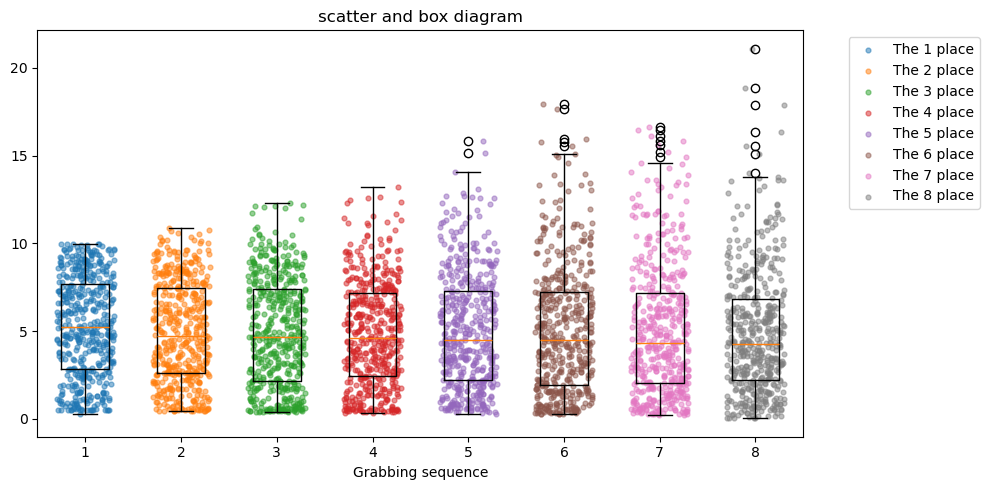

In [178]:
# 准备箱线图数据
box_data = [
    long_df[long_df["pos_id"] == pos]["amount"].values
    for pos in sorted(long_df["pos_id"].unique())
]
# 6. 散点图（不同位次不同颜色）
plt.figure(figsize=(10, 5))
plt.boxplot(box_data, showfliers=True)

positions = sorted(long_df["pos_id"].unique())
# 每列宽度（以 x 轴单位计），点在该宽度内均匀分布
col_width = 0.6
# 散点大小（marker area），确保点宽小于列宽
marker_size = 12

for idx, pos in enumerate(positions):
    y = long_df[long_df["pos_id"] == pos]["amount"].values
    n = len(y)
    if n == 0:
        continue
    # 在列范围内均匀随机分布 x，避免集中在同一竖线
    left = pos - col_width / 2 + 1e-6
    right = pos + col_width / 2 - 1e-6
    x = np.random.uniform(left, right, size=n)
    # 仅为第一个位置添加图例，避免重复图例项
    label = f"The {pos} place" 
    plt.scatter(x, y, alpha=0.5, s=marker_size, label=label)

plt.xlabel("Grabbing sequence")
plt.ylabel("")
plt.title("scatter and box diagram")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 画直方图（看分布形态）

这是根据导入数据生成的频率直方图，bin_width可以调节宽度

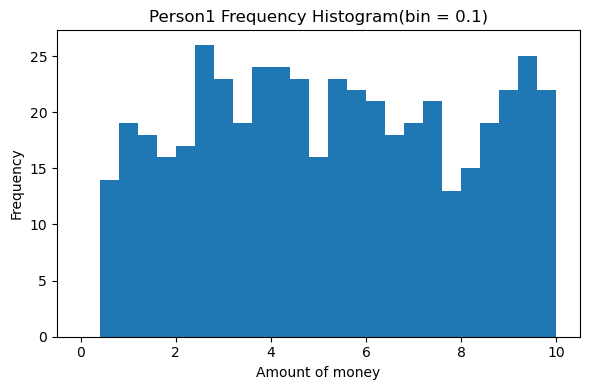

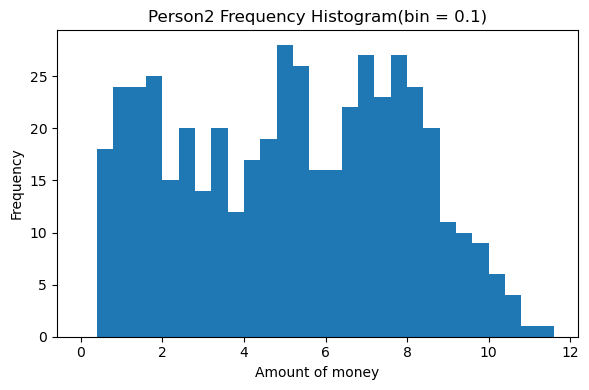

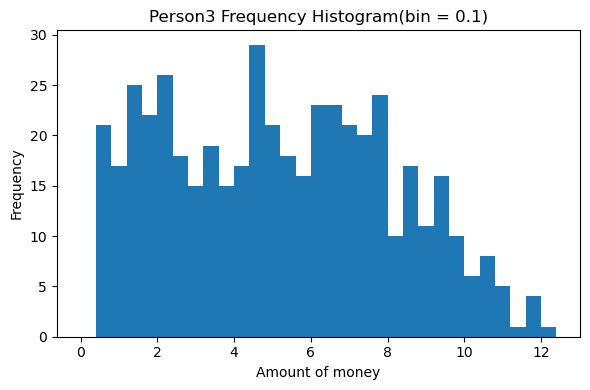

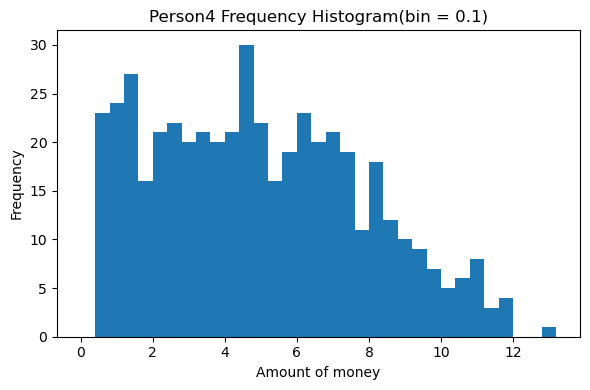

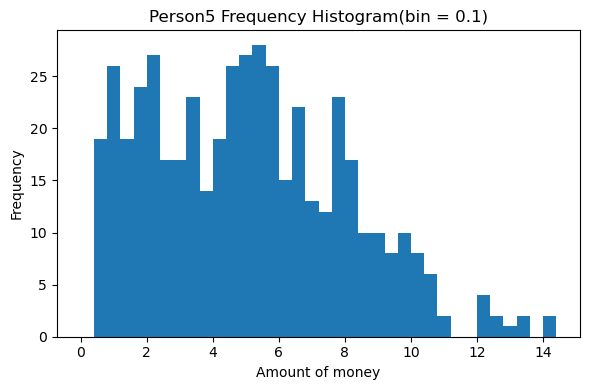

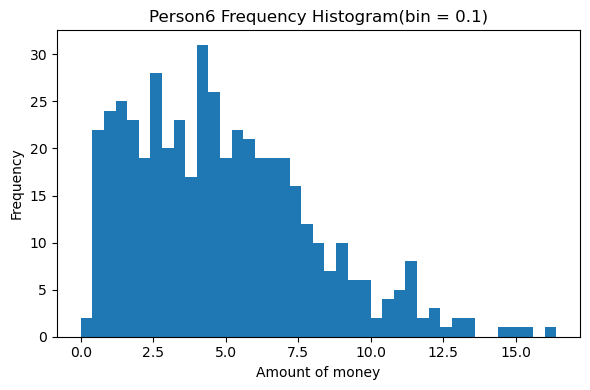

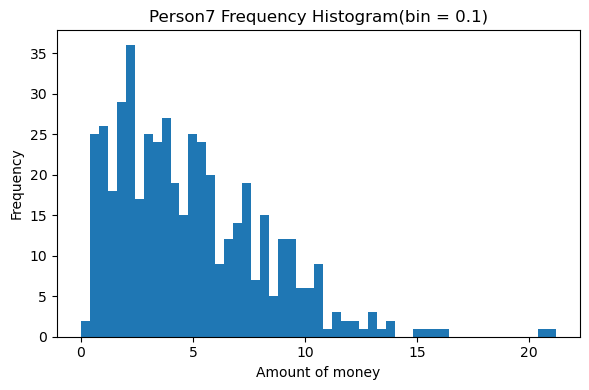

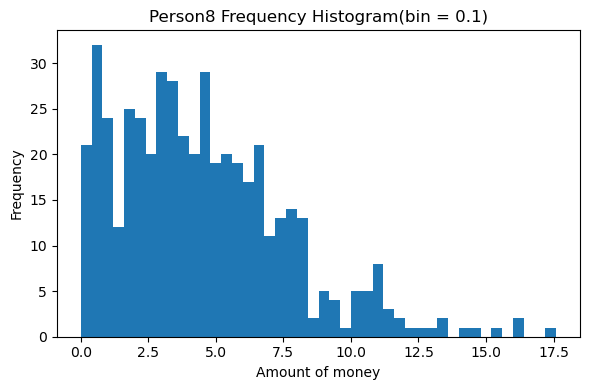

                bin_left  bin_right  count
position index                            
Person1  0           0.0        0.4      0
         1           0.4        0.8     14
         2           0.8        1.2     19
         3           1.2        1.6     18
         4           1.6        2.0     16


In [161]:
# 4. 直方图区间宽度
bin_width = 0.4

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

这是用Diffusion生成数据的直方图，可以与前面的直方图进行对比。

position_1


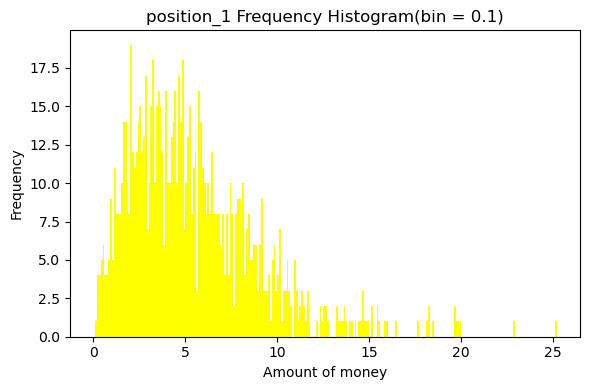

position_2


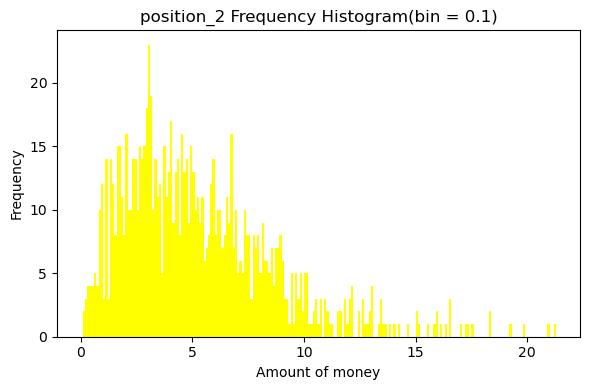

position_3


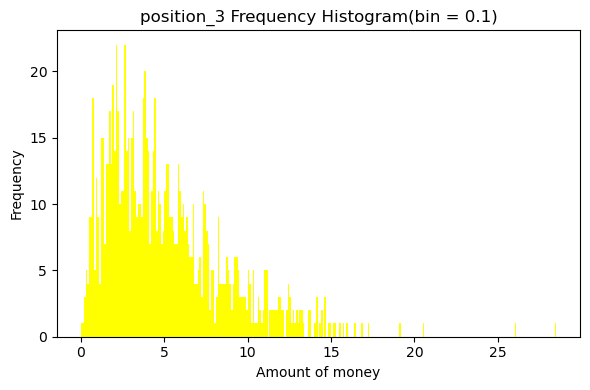

position_4


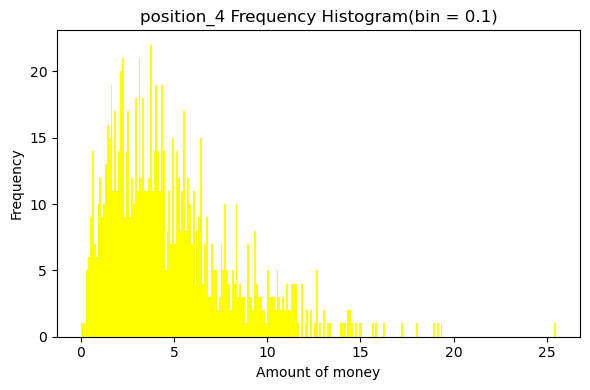

position_5


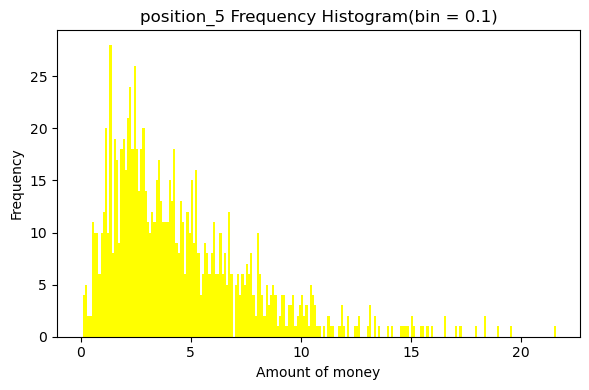

position_6


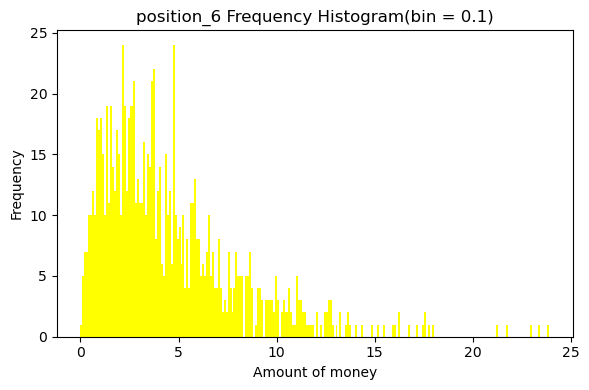

position_7


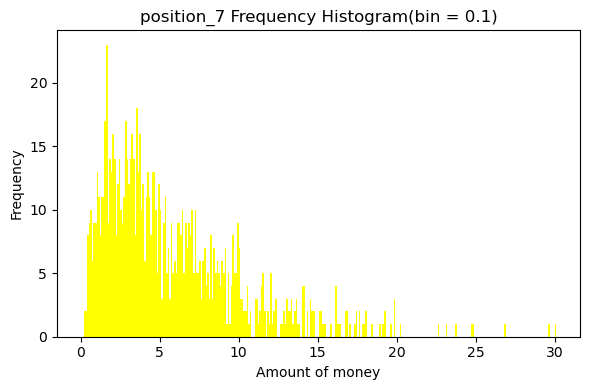

position_8


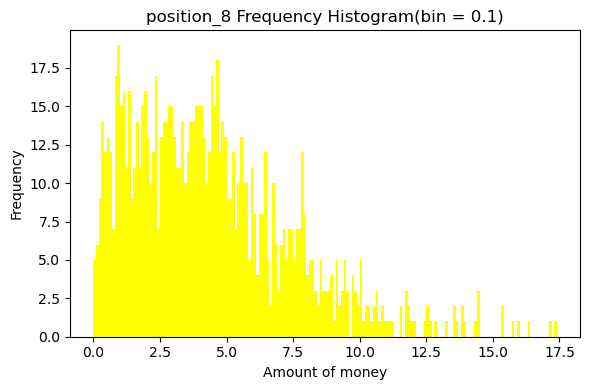

                  bin_left  bin_right  count
position   index                            
position_1 0           0.0        0.1      0
           1           0.1        0.2      1
           2           0.2        0.3      4
           3           0.3        0.4      4
           4           0.4        0.5      5


In [168]:
# 4. 直方图区间宽度
bin_width = 0.1

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    print(col)
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.hist(values, bins=bins, color='yellow')
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())